# **Markov Decision Processes**

### 1. Introduction to MDPs

In the last notebook, we introduced MAB problems that acquainted us with RL fundamentals such as actions, rewards and the trade-off between exploration and exploitation. However, MABs are simplistic in that each one-armed bandit has a fixed reward distribution. In other words, rewards given to the agent are not dependent on the previously taken actions (which bandit machines were pulled beforehand), known as the history. To discuss problems where this is not the case, previous actions taken by the agent do change the distribution of expected rewards, we will consider Markov Decision Processes (MDPs). MDPs are built on top of Markov chains. Namely, they model sequences of possible events using the Markov property, which assumes that the probability of the next state and reward depends only on the current state of the system and the agent's action. We can imagine MDP as the default framework for RL algorithms. In practice, most RL algorithms are derived under the assumption that the environment can be modelled with the Markov property. Therefore, it is essential to develop a deep understanding of the RL framework through MDPs as a fundamental model.

### 2. Markov Chain Basics

Markov chains allow us to model sequences of possible events where the probability of an event occuring depends only on the event that occured before it it. In the language of Markov chains, an event is when the described system transitions into a state. As an example, let us consider the following system which can only exist in two states: $A$ and $E$,

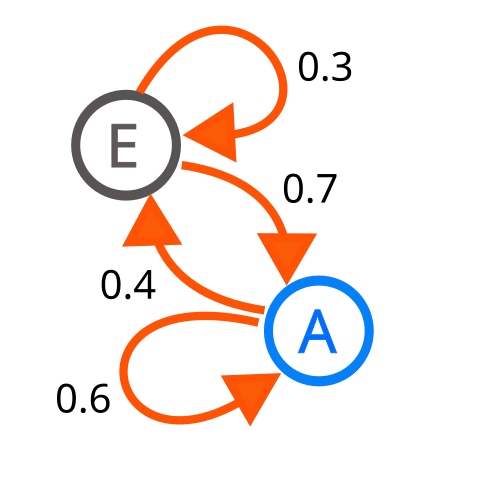

In total, we have four transition probabilities describing the transition. They are:
- (a) $A \longrightarrow E$ 
- (b) $E \longrightarrow A$ 
- (c) $A \longrightarrow A$
- (d) $E \longrightarrow E$

Notice that we include transitions that begin and end with the systems in the same state. Each transition has probability of occuring. For example, $A \longrightarrow E$ has the transition probability $P(E \vert A) = 0.4$. On our node diagram, all the probabilities from a node must sun up to one such that probability is conserved. We can take random walks along a chain by sequentially considering the probability of each transition. From this random walk, we can compute the probability of the system being in a given state. In our case, we have $P(A)$ and $P(E)$. Let us use Python to simulate this, 

In [ ]:
# Importing,
import numpy as np

def next_state(current_state):
    """Returns the next state of the system provides the current state. 0 represents state A while 1 refers to state E."""

    # Current state is A,
    if current_state == 0:
        if np.random.uniform(low=0, high=1, size=1) < 0.4:
            next_state = 1
        else:
            next_state = 0

    # Current state is E,
    if current_state == 1:
        if np.random.uniform(low=0, high=1, size=1) < 0.3:
            next_state = 1
        else:
            next_state = 0

    return next_state

# Simulating random walk,
N = 10000

current_state = 0 # <-- System is initially in state A.
count = 0
for t in range(N):
    current_state = next_state(current_state)
    count += current_state

# Computing probabilities,
probs_E = count/N
probs_A = 1 - probs_E
print(f"P(E) = {(probs_E)}, P(A) = {(probs_A)}")

P(E) = 0.3625, P(A) = 0.6375


Notice that for large $N$, the number of iterations in the random walk, $P(A)$ and $P(E)$ reach stable values.

### 3. Markov Decision Processes

In the notebook _Introduction to Reinforcement Learning_, we covered the fundamental problem statement of RL: the interaction between an agent and environment via rewards, actions and state transitions. Now we establish this problem statement more rigorously in mathematical language. We start with the agent that can take an action $A_t$ at time $t$ against the environment. Upon being acted on by the agent through the actions $A_t$, the environment produces a reward $R_{t+1}$ and undergoes a state change from $S$ to $S_{t+1}$. This process repeats in the classic RL loop (see the diagram below),


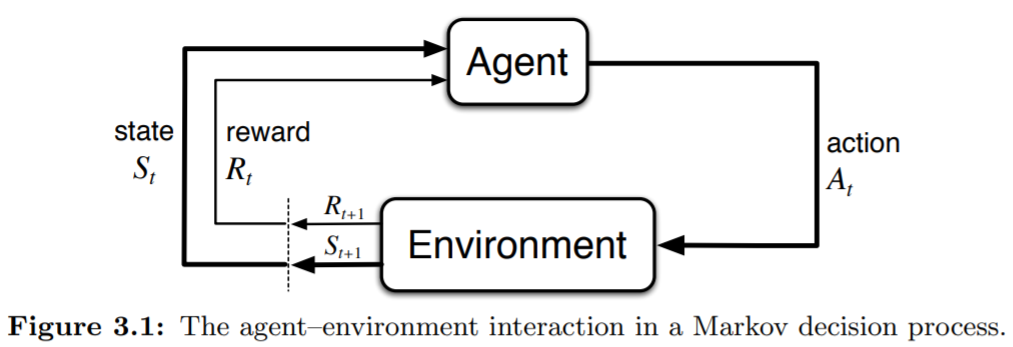

Note that time is discrete such that $t \in  \{ 0, 1, 2, 3, ... \}$ while $S$, $A$ and $R$ represent random variables for the system state, action and reward respectively. Our trajectory or interaction sequence (agent and enviroment interacting with each other) can then be written as,

$$
S_t \rightarrow A_t \rightarrow R_{t+1}, \; S_{t+1}
\rightarrow A_{t+1} \rightarrow R_{t+2}, \; S_{t+2}
\rightarrow \cdots
$$

Our random variables $S$, $A$ and $R$ can take on the values $s$, $a$ and $r$. $s \in \mathcal{S}$ where $\mathcal{S}$ is the set of all possible states the system can be in at some time $t$. The set of actions the agent can take is dependent on the state that the system (environment) is in $s$ such that $a \in \mathcal{A}(s)$. Note that, $\mathcal{A}(s)$ is the set of all possible actions the agent can take when the environment is in the state $s$. Finally, the reward may be any real number so that $r \in \mathcal{R}$. The dynamics of the agent-environment interaction is then specified by,

$$
P(s', r \vert s, a) = \text{Prob}(S_{t+1} = s', R_{t+1} = r \vert S_t = s, A_t = a)
$$

Alternatively,

$$
P(s', r \vert s, a) = \text{Prob}(S_{t+1} = s', R_{t+1} = r \vert S_1, A_1, S_2, A_2, ..., S_t = s, A_t = a)
$$

This is Markov property in the context of RL; the defining aspect of MDPs. It tell us that probability of the agent receiving the reward $r$ from taking an action $a$ is only dependent on the state transition of the environment from $s$ to $s'$; not the full trajectory so far. Let us now discuss the agent's behaviour which is governed by the **policy**. The policy function $\pi(a \vert s)$ is a probability distribution that gives the probability the agent will take some action $a$ given that the environment is in a state $s$ over all possible actions $\mathcal{A}(s)$. When our policy is stochastic, the agent selects an action in accordance with the policy function $\pi(a \vert s)$. However, when the agent is deterministic, $a = \pi(s)$ where $\pi(s)$ is now a function that maps each state directly to a single action instead of a probability distribution. Our objective is to find the optimal policy $\pi^*$ that maximises the expected value of the **return**. We define the return as the accumulation of rewards $G_t$ over each iteration discounted with the discount factor $\gamma \in [0, 1]$,

$$
G_t = \sum^{T}_{k=t+1} \gamma^{k-t-1} R_k = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} ... + \gamma^{T-t-1} R_{T}
$$

where $T$ is the number of iterations or episodes in the trajectory. $\gamma$ tell us how much the agent should consider future rewards; delayed gratification. Larger values of $\gamma$ weigh future rewards more heavily. $\gamma$ close to 0 leads to _"myopic"_ evaluation while $\gamma$ close to 1 is _"far-sighted"_ evaluation. Finding the optimial policy is then formulated as the following optimisation problem,

$$
\pi^* = \text{max}_{\pi} \mathbf{E}[G_t]
$$


### 4. Grid Example

### 5. The Bellman Equations

Computing $\mathbf{E}[G_t]$ to find the optimum policy $\pi^*$ requires computing the many possible trajectories for many possible policies, which quickly becomes computationally infeasible. In MDPs, we instead define a **state-value function** $v_{\pi}(s)$ which assigns a value corresponding to the expected future rewards obtained when following policy $\pi$ to each state. In other words, the value function allows us to quantify the goodness/badness of starting in some state by considering its expected long-term usefulness. By definition, the state-value function $v_{\pi}(s)$ is the expected return starting from state $s$ (when following some policy $\pi$),

$$
v_{\pi}(s) = \mathbf{E}_{\pi}[G_t \vert S_t = s]
$$

It can be shown that the optimum policy $\pi^*$ is the policy whose state-value function dominates all others,

$$
v_{\pi^*}(s) \geq v_{\pi}(s) \quad \forall \quad s, \pi
$$

Analogous to the state value function is the **action-value function** $q_{\pi}(s, a)$ which considers action-state pairs rather than only states. Likewise, for the optimum policy $\pi^*$,

$$
q_{\pi}(s, a) = \mathbf{E}_{\pi}[G_t \vert S_t = s, A_t = a]
$$

$$
q_{\pi^*}(s, a) \geq q_{\pi}(s, a) \quad \forall \quad s,a, \pi
$$

Let us consider the total return $G_t$ in the definition of $v_{\pi}(s)$. We can replace it with its recursive relationship $G_t = R_{t+1} + \gamma G_{t+1}$ that tell us [...]. In doing so, we find a recursive relationship for the state-value function itself,

\begin{align}
v_\pi(s)
&= \mathbf{E}_{\pi}[G_t \vert S_t = s] \\
&= \mathbf{E}_{\pi}\left[R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots \mid S_t = s\right] \\
&= \mathbf{E}_{\pi}\left[R_{t+1} + \gamma (R_{t+2} + \gamma R_{t+3} + \cdots ) \mid S_t = s\right] \\
&= \mathbf{E}_{\pi}\left[R_{t+1} + \gamma G_{t+1} \mid S_t = s\right] \\
&= \mathbf{E}_{\pi}\left[\mathbf{E}_{\pi}[R_{t+1} \mid S_t = s] + \mathbf{E}_{\pi}[\gamma G_{t+1} \mid S_t = s] \mid S_t = s\right] \\
&= \mathbf{E}_{\pi}\left[R_{t+1} + \gamma v_\pi(S_{t+1}) \mid S_t = s\right]
\end{align}

where we have used the property that the expection of the expection is simply just the expectation (law of total expectation). Using the same logic, we can derive the same property for the action-value function,

$$
q_\pi(s, a) = \mathbf{E}_{\pi}\left[R_{t+1} + \gamma q_\pi(S_{t+1}, A_{t+1}) \mid S_t = s, A_t = a\right]
$$


Let again consider the state-value function, $v_{\Pi}$, if we think deeply enough, we can rewrite it in an alternate way. Since $v_{\Pi}$ is the expected return of the agent when the environment is in some state $s$, it must be dependent on the future actions taken by agent starting from the state $s$. Recall that our policy function $\Pi(a \vert s)$ tells us the probability that the agent performs action $a$ given that we are in state $s$ (stochastic case). It follows that the expected return should be the following weighted sum, 

$$
v_{\Pi} = \sum_{a \in \mathcal{A(s)}} \Pi(a \vert s) \mathbf{E}_{\Pi}[G_t \vert s, a]
$$

where we are considering the expected reward arising from the agent taking the action $a$ while the environment in state $s$. We consider all actions $a$ that are in the space of all possible actions if the environment is in state $s$. Notice that $\mathbf{E}_{\Pi}[G_t \vert s, a]$ is the definition of the action-value function such that we have, 

$$
v_{\Pi} = \sum_{a \in \mathcal{A(s)}} \Pi(a \vert s) q_{\Pi}(s, a)
$$

### References

Lecture 16: Markov Chains - https://www.youtube.com/watch?v=IkbkEtOOC1Y

Reinforcement Learning By the Book: https://www.youtube.com/watch?v=NFo9v_yKQXA&list=PLzvYlJMoZ02Dxtwe-MmH4nOB5jYlMGBjr

Fundamentals of Reinforcement Learning - Finite Markov Decision Processes: https://lrscy.github.io/2020/03/03/Coursera-Reinforcement-Learning-Course1-Week2-Notes/

Reinforcement Learning by David Silver: https://www.youtube.com/watch?v=2pWv7GOvuf0&list=PLzuuYNsE1EZAXYR4FJ75jcJseBmo4KQ9-